In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy
import pymysql
import urllib.parse
from sqlalchemy import create_engine, text
from sqlalchemy import inspect
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

print("Pandas:", pd.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)
print("PyMySQL:", pymysql.__version__)

Pandas: 3.0.6
SQLAlchemy: 2.0.25
PyMySQL: 2.2.8


In [2]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [3]:
username = "root"
password = "Vinimesh@2003"

# URL-encode the password to safely handle special characters like '@'
encoded_password = urllib.parse.quote_plus(password)

# Using 127.0.0.1 to perfectly match your Workbench configuration
host = "127.0.0.1" 
port = 3306
database = "ecommerce_analytics"

engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
)

with engine.connect() as connection:
    result = connection.execute(text("SELECT VERSION()"))
    print("Connected to MySQL:", result.fetchone()[0])

Connected to MySQL: 8.0.46


In [4]:
inspector = inspect(engine)

print(inspector.get_table_names())

['customer_rfm', 'online_retail_clean', 'online_retail_raw']


In [5]:
print("Numpy", np.__version__)

Numpy 2.4.6


In [6]:
from sqlalchemy import create_engine, text

username = "root"
password = "Vinimesh@2003"
encoded_password = urllib.parse.quote_plus(password)
host = "127.0.0.1"
port = 3306
database = "ecommerce_analytics"

engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
)

print(type(engine))

<class 'sqlalchemy.engine.base.Engine'>


In [7]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT VERSION()"))
    print("Connected to MySQL:", result.fetchone()[0])

Connected to MySQL: 8.0.46


In [8]:
import pandas as pd
from sqlalchemy import text

with engine.connect() as connection:
    # 1. Execute the query using SQLAlchemy natively
    result = connection.execute(text("SELECT COUNT(*) AS total_rows FROM online_retail_raw"))
    
    # 2. Build the DataFrame directly from the fetched rows and column keys
    check = pd.DataFrame(result.fetchall(), columns=result.keys())

print(check)

   total_rows
0      541909


In [9]:
csv_path = r"C:\Users\dell\Downloads\Online_Retail.csv"

df_test = pd.read_csv(csv_path)

print("Rows:", len(df_test))
print("Columns:", df_test.columns.tolist())

Rows: 541909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [10]:
df_test.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [11]:
df_test.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [12]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.8 MB


In [13]:
csv_path = r"C:\Users\dell\Downloads\Online_Retail.csv"

chunk_size = 10000
total_imported = 0

for chunk in pd.read_csv(
    csv_path,
    chunksize=chunk_size
):
    
    chunk.to_sql(
        "online_retail_raw",
        con=engine,
        if_exists="append",
        index=False,
        method="multi"
    )
    
    total_imported += len(chunk)
    
    print(f"Imported: {total_imported:,} rows")

Imported: 10,000 rows
Imported: 20,000 rows
Imported: 30,000 rows
Imported: 40,000 rows
Imported: 50,000 rows
Imported: 60,000 rows
Imported: 70,000 rows
Imported: 80,000 rows
Imported: 90,000 rows
Imported: 100,000 rows
Imported: 110,000 rows
Imported: 120,000 rows
Imported: 130,000 rows
Imported: 140,000 rows
Imported: 150,000 rows
Imported: 160,000 rows
Imported: 170,000 rows
Imported: 180,000 rows
Imported: 190,000 rows
Imported: 200,000 rows
Imported: 210,000 rows
Imported: 220,000 rows
Imported: 230,000 rows
Imported: 240,000 rows
Imported: 250,000 rows
Imported: 260,000 rows
Imported: 270,000 rows
Imported: 280,000 rows
Imported: 290,000 rows
Imported: 300,000 rows
Imported: 310,000 rows
Imported: 320,000 rows
Imported: 330,000 rows
Imported: 340,000 rows
Imported: 350,000 rows
Imported: 360,000 rows
Imported: 370,000 rows
Imported: 380,000 rows
Imported: 390,000 rows
Imported: 400,000 rows
Imported: 410,000 rows
Imported: 420,000 rows
Imported: 430,000 rows
Imported: 440,000 ro

In [13]:
query = """
SELECT
    CustomerID,
    Recency,
    Frequency,
    Monetary
FROM customer_rfm
"""

with engine.connect() as connection:
    result = connection.execute(text(query))
    
    rfm = pd.DataFrame(result.fetchall(), columns=result.keys())

print("Shape:", rfm.shape)
print(rfm.head())

Shape: (4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        3          7   4310.00
2       12348       76          4   1797.24
3       12349       19          1   1757.55
4       12350      311          1    334.40


In [14]:
rfm.describe()

,CustomerID,Recency,Frequency
count,4338.000000,4338.000000,4338.000000
mean,15300.408022,93.059474,4.272015
std,1721.808492,100.012264,7.697998
min,12346.000000,1.000000,1.000000
25%,13813.250000,18.000000,1.000000
50%,15299.500000,51.000000,2.000000
75%,16778.750000,142.750000,5.000000
max,18287.000000,374.000000,209.000000


In [15]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.245826
Frequency    12.067031
Monetary     19.324953
dtype: object

In [16]:
rfm_log = rfm.copy()

rfm_log["Recency"] = rfm_log["Recency"].astype(float)
rfm_log["Frequency"] = rfm_log["Frequency"].astype(float)
rfm_log["Monetary"] = rfm_log["Monetary"].astype(float)

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

print(rfm_log[["Recency", "Frequency", "Monetary"]].skew())

Recency     -0.326852
Frequency    1.208652
Monetary     0.393553
dtype: float64


In [17]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.478884,-0.955214,3.706225
1,-1.890642,1.074425,1.411843
2,0.372339,0.386304,0.716489
3,-0.659158,-0.955214,0.698739
4,1.442954,-0.955214,-0.618962


In [18]:
print("Means:")
print(rfm_scaled.mean())

print("\nStandard deviations:")
print(rfm_scaled.std())

Means:
Recency      7.698365e-17
Frequency   -8.189750e-18
Monetary     3.931080e-17
dtype: float64

Standard deviations:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


In [19]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

for k, wcss, sil in zip(K_range, inertia, silhouette_scores):
    print(f"K={k}: WCSS={wcss:.2f}, Silhouette={sil:.4f}")

K=2: WCSS=6474.15, Silhouette=0.4326
K=3: WCSS=4856.59, Silhouette=0.3364
K=4: WCSS=3924.46, Silhouette=0.3355
K=5: WCSS=3268.21, Silhouette=0.3182
K=6: WCSS=2840.15, Silhouette=0.3156
K=7: WCSS=2533.02, Silhouette=0.3101
K=8: WCSS=2325.52, Silhouette=0.3020
K=9: WCSS=2145.04, Silhouette=0.2812
K=10: WCSS=1990.13, Silhouette=0.2763


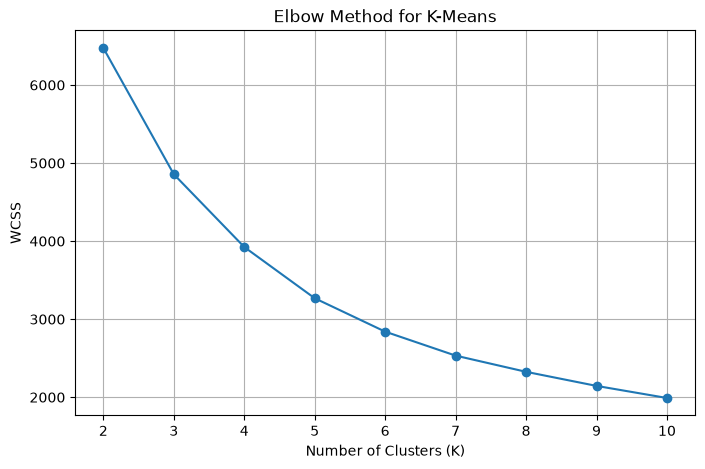

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.xticks(K_range)
plt.grid(True)
plt.show()

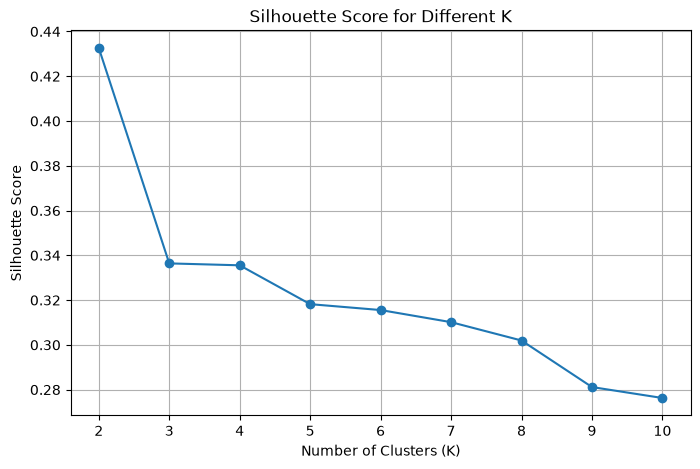

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0     877
1    1579
2     720
3    1162
Name: count, dtype: int64


In [23]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={
    "CustomerID": "CustomerCount"
})

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,20.564424,2.045610,527.174401,877
1,187.675111,1.332489,352.12582,1579
2,12.509722,13.655556,8037.205444,720
3,69.114458,4.132530,1812.634561,1162


In [24]:
cluster_labels = {
    0: "Regular Customers",
    1: "At-Risk / Inactive Customers",
    2: "High-Value Loyal Customers",
    3: "Recent Low-Frequency Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Recent Low-Frequency Customers
1,12347,3,7,4310.00,2,High-Value Loyal Customers
2,12348,76,4,1797.24,3,Recent Low-Frequency Customers
3,12349,19,1,1757.55,0,Regular Customers
4,12350,311,1,334.40,1,At-Risk / Inactive Customers


In [25]:
cluster_median = rfm.groupby("Segment").agg({
    "Recency": "median",
    "Frequency": "median",
    "Monetary": "median",
    "CustomerID": "count"
}).rename(columns={
    "CustomerID": "CustomerCount"
})

cluster_median

,Recency,Frequency,Monetary,CustomerCount
Segment,,,,
At-Risk / Inactive Customers,183.0,1.0,300.42,1579
High-Value Loyal Customers,9.0,10.0,3726.08,720
Recent Low-Frequency Customers,54.0,4.0,1353.74,1162
Regular Customers,19.0,2.0,450.84,877


In [28]:
with engine.connect() as connection:
    transactions = pd.read_sql(
        text("""
            SELECT
                InvoiceNo,
                Description
            FROM online_retail_clean
            WHERE Description IS NOT NULL
              AND TRIM(Description) <> ''
        """),
        connection
    )

print("Shape:", transactions.shape)
transactions.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_20840\1648806126.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(


TypeError: Query must be a string unless using sqlalchemy.

In [29]:
import pandas as pd
from sqlalchemy import text

query = """
    SELECT
        InvoiceNo,
        Description
    FROM online_retail_clean
    WHERE Description IS NOT NULL
      AND TRIM(Description) <> ''
"""

with engine.connect() as connection:
    # Execute the query using SQLAlchemy natively
    result = connection.execute(text(query))
    
    # Build the DataFrame directly from the fetched rows
    transactions = pd.DataFrame(result.fetchall(), columns=result.keys())

print("Shape:", transactions.shape)
print(transactions.head())

Shape: (397880, 2)
  InvoiceNo                          Description
0    536365   WHITE HANGING HEART T-LIGHT HOLDER
1    536365                  WHITE METAL LANTERN
2    536365       CREAM CUPID HEARTS COAT HANGER
3    536365  KNITTED UNION FLAG HOT WATER BOTTLE
4    536365       RED WOOLLY HOTTIE WHITE HEART.


In [30]:
transactions = transactions.drop_duplicates(
    subset=["InvoiceNo", "Description"]
)

print("Shape after removing duplicates:", transactions.shape)

Shape after removing duplicates: (387658, 2)


In [31]:
print("Unique invoices:", transactions["InvoiceNo"].nunique())
print("Unique products:", transactions["Description"].nunique())

Unique invoices: 18532
Unique products: 3865


In [32]:
basket = (
    transactions
    .assign(value=1)
    .pivot_table(
        index="InvoiceNo",
        columns="Description",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

print("Basket shape:", basket.shape)
basket.head()

Basket shape: (18532, 3865)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
basket

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [34]:
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.01,
    use_colnames=True
)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(20)

C:\Users\dell\AppData\Roaming\Python\Python311\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 973


,support,itemsets
0,0.106357,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
253,0.091895,frozenset({REGENCY CAKESTAND 3 TIER})
88,0.086337,frozenset({JUMBO BAG RED RETROSPOT})
438,0.074412,frozenset({PARTY BUNTING})
7,0.074196,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
41,0.069501,frozenset({LUNCH BAG RED RETROSPOT})
465,0.061839,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
18,0.059303,frozenset({POSTAGE})
157,0.056767,frozenset({LUNCH BAG BLACK SKULL.})
42,0.055526,frozenset({PACK OF 72 RETROSPOT CAKE CASES})


In [35]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

print("Number of association rules:", len(rules))

Number of association rules: 612


In [36]:
rules.sort_values(
    by="lift",
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
576,frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE PINK}),0.014569,0.012087,0.010900,0.748148,61.895899,1.0,0.010724,3.922595,0.998390,0.691781,0.745067,0.824967
577,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN}),0.012087,0.014569,0.010900,0.901786,61.895899,1.0,0.010724,10.033475,0.995881,0.691781,0.900334,0.824967
394,frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",0.013598,0.013706,0.010037,0.738095,53.851894,1.0,0.009850,3.765850,0.994960,0.581250,0.734456,0.735189
389,"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),0.013706,0.013598,0.010037,0.732283,53.851894,1.0,0.009850,3.684501,0.995069,0.581250,0.728593,0.735189
572,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.014461,0.014677,0.011116,0.768657,52.370391,1.0,0.010904,4.259137,0.995299,0.616766,0.765211,0.763005
573,frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.014677,0.014461,0.011116,0.757353,52.370391,1.0,0.010904,4.061613,0.995517,0.616766,0.753792,0.763005
391,"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE BEDROOM}),0.011602,0.017052,0.010037,0.865116,50.735237,1.0,0.009839,7.287376,0.991796,0.539130,0.862776,0.726862
392,frozenset({POPPY'S PLAYHOUSE BEDROOM}),"frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...",0.017052,0.011602,0.010037,0.588608,50.735237,1.0,0.009839,2.402569,0.997295,0.539130,0.583779,0.726862
579,frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE PINK}),0.017699,0.012087,0.010630,0.600610,49.689732,1.0,0.010416,2.473553,0.997531,0.554930,0.595723,0.740037
578,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES}),0.012087,0.017699,0.010630,0.879464,49.689732,1.0,0.010416,8.149459,0.991864,0.554930,0.877292,0.740037


In [37]:
id="8m4k2p"
rules_clean = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules_clean.head()

,antecedents,consequents,support,confidence,lift
0,frozenset({HAND WARMER OWL DESIGN}),frozenset({HAND WARMER UNION JACK}),0.011278,0.365385,15.354439
1,frozenset({HAND WARMER UNION JACK}),frozenset({HAND WARMER OWL DESIGN}),0.011278,0.473923,15.354439
2,frozenset({HAND WARMER SCOTTY DOG DESIGN}),frozenset({HAND WARMER UNION JACK}),0.010253,0.403397,16.951822
3,frozenset({HAND WARMER UNION JACK}),frozenset({HAND WARMER SCOTTY DOG DESIGN}),0.010253,0.430839,16.951822
4,frozenset({HOME BUILDING BLOCK WORD}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.011278,0.302460,2.843832


In [38]:
rules_clean["antecedents"] = rules_clean["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules_clean["consequents"] = rules_clean["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules_clean.head(10)

,antecedents,consequents,support,confidence,lift
0,HAND WARMER OWL DESIGN,HAND WARMER UNION JACK,0.011278,0.365385,15.354439
1,HAND WARMER UNION JACK,HAND WARMER OWL DESIGN,0.011278,0.473923,15.354439
2,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER UNION JACK,0.010253,0.403397,16.951822
3,HAND WARMER UNION JACK,HAND WARMER SCOTTY DOG DESIGN,0.010253,0.430839,16.951822
4,HOME BUILDING BLOCK WORD,WHITE HANGING HEART T-LIGHT HOLDER,0.011278,0.302460,2.843832
5,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,0.014839,0.397974,13.288745
6,LOVE BUILDING BLOCK WORD,HOME BUILDING BLOCK WORD,0.014839,0.495495,13.288745
7,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE KITCHEN,0.013706,0.803797,43.051950
8,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE BEDROOM,0.013706,0.734104,43.051950
9,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.028599,0.604333,14.194548


In [39]:
rules_clean = rules_clean.sort_values(
    by="lift",
    ascending=False
).reset_index(drop=True)

rules_clean.head(20)

,antecedents,consequents,support,confidence,lift
0,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.010900,0.748148,61.895899
1,REGENCY TEA PLATE PINK,REGENCY TEA PLATE GREEN,0.010900,0.901786,61.895899
2,POPPY'S PLAYHOUSE LIVINGROOM,"POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE K...",0.010037,0.738095,53.851894
3,"POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE K...",POPPY'S PLAYHOUSE LIVINGROOM,0.010037,0.732283,53.851894
4,REGENCY SUGAR BOWL GREEN,REGENCY MILK JUG PINK,0.011116,0.768657,52.370391
5,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.011116,0.757353,52.370391
6,"POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE L...",POPPY'S PLAYHOUSE BEDROOM,0.010037,0.865116,50.735237
7,POPPY'S PLAYHOUSE BEDROOM,"POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE L...",0.010037,0.588608,50.735237
8,REGENCY TEA PLATE ROSES,REGENCY TEA PLATE PINK,0.010630,0.600610,49.689732
9,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.010630,0.879464,49.689732


In [40]:
# Keep strong and practical recommendation rules
recommendation_rules = rules_clean[
    (rules_clean["support"] >= 0.01) &
    (rules_clean["confidence"] >= 0.50) &
    (rules_clean["lift"] >= 2.0) &
    (~rules_clean["consequents"].str.contains(","))
].copy()

print("Recommendation rules:", len(recommendation_rules))

recommendation_rules.head(20)

Recommendation rules: 265


,antecedents,consequents,support,confidence,lift
0,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK,0.010900,0.748148,61.895899
1,REGENCY TEA PLATE PINK,REGENCY TEA PLATE GREEN,0.010900,0.901786,61.895899
3,"POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE K...",POPPY'S PLAYHOUSE LIVINGROOM,0.010037,0.732283,53.851894
4,REGENCY SUGAR BOWL GREEN,REGENCY MILK JUG PINK,0.011116,0.768657,52.370391
5,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN,0.011116,0.757353,52.370391
6,"POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE L...",POPPY'S PLAYHOUSE BEDROOM,0.010037,0.865116,50.735237
8,REGENCY TEA PLATE ROSES,REGENCY TEA PLATE PINK,0.010630,0.600610,49.689732
9,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES,0.010630,0.879464,49.689732
10,"POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE L...",POPPY'S PLAYHOUSE KITCHEN,0.010037,0.907317,48.596532
12,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.012357,0.848148,47.920370


In [41]:
rfm_export = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Cluster",
        "Segment"
    ]
].copy()

rfm_export.to_csv(
    r"C:\Users\dell\Downloads\customer_segments.csv",
    index=False
)

print("Customer segmentation exported successfully.")
print("Rows:", len(rfm_export))

Customer segmentation exported successfully.
Rows: 4338


In [42]:
recommendation_rules.to_csv(
    r"C:\Users\dell\Downloads\recommendation_rules.csv",
    index=False
)

print("Recommendation rules exported successfully.")
print("Rows:", len(recommendation_rules))

Recommendation rules exported successfully.
Rows: 265
